In [2]:
import pandas as pd

df = pd.read_csv("Student Mental health.csv")
print(df.shape)
df.head()

(101, 11)


,Timestamp,Choose your gender,Age,What is your course?,Your current year of Study,What is your CGPA?,Marital status,Do you have Depression?,Do you have Anxiety?,Do you have Panic attack?,Did you seek any specialist for a treatment?
0,8/7/2020 12:02,Female,18.0,Engineering,year 1,3.00 - 3.49,No,Yes,No,Yes,No
1,8/7/2020 12:04,Male,21.0,Islamic education,year 2,3.00 - 3.49,No,No,Yes,No,No
2,8/7/2020 12:05,Male,19.0,BIT,Year 1,3.00 - 3.49,No,Yes,Yes,Yes,No
3,8/7/2020 12:06,Female,22.0,Laws,year 3,3.00 - 3.49,Yes,Yes,No,No,No
4,8/7/2020 12:13,Male,23.0,Mathemathics,year 4,3.00 - 3.49,No,No,No,No,No


In [3]:
# Check column names clearly
print(df.columns.tolist())

# Check for missing values
print("\nMissing values:")
print(df.isnull().sum())

# Basic stats
print("\nBasic info:")
print(df.info())


['Timestamp', 'Choose your gender', 'Age', 'What is your course?', 'Your current year of Study', 'What is your CGPA?', 'Marital status', 'Do you have Depression?', 'Do you have Anxiety?', 'Do you have Panic attack?', 'Did you seek any specialist for a treatment?']

Missing values:
Timestamp                                       0
Choose your gender                              0
Age                                             1
What is your course?                            0
Your current year of Study                      0
What is your CGPA?                              0
Marital status                                  0
Do you have Depression?                         0
Do you have Anxiety?                            0
Do you have Panic attack?                       0
Did you seek any specialist for a treatment?    0
dtype: int64

Basic info:
<class 'pandas.DataFrame'>
RangeIndex: 101 entries, 0 to 100
Data columns (total 11 columns):
 #   Column                                     

In [5]:

# Rename columns to shorter names (easier to work with)
df.columns = ['Timestamp', 'Gender', 'Age', 'Course', 'Year', 'CGPA', 'Married', 'Depression', 'Anxiety', 'Panic_Attack', 'Sought_Help']

# Fix for newer pandas - fill missing age correctly
df['Age'] = df['Age'].fillna(df['Age'].mean())

# Check everything is clean now
print("Missing values after cleaning:")
print(df.isnull().sum())

print("\nData sample:")
df.head()

Missing values after cleaning:
Timestamp       0
Gender          0
Age             0
Course          0
Year            0
CGPA            0
Married         0
Depression      0
Anxiety         0
Panic_Attack    0
Sought_Help     0
dtype: int64

Data sample:


,Timestamp,Gender,Age,Course,Year,CGPA,Married,Depression,Anxiety,Panic_Attack,Sought_Help
0,8/7/2020 12:02,Female,18.0,Engineering,year 1,3.00 - 3.49,No,Yes,No,Yes,No
1,8/7/2020 12:04,Male,21.0,Islamic education,year 2,3.00 - 3.49,No,No,Yes,No,No
2,8/7/2020 12:05,Male,19.0,BIT,Year 1,3.00 - 3.49,No,Yes,Yes,Yes,No
3,8/7/2020 12:06,Female,22.0,Laws,year 3,3.00 - 3.49,Yes,Yes,No,No,No
4,8/7/2020 12:13,Male,23.0,Mathemathics,year 4,3.00 - 3.49,No,No,No,No,No


Matplotlib is building the font cache; this may take a moment.


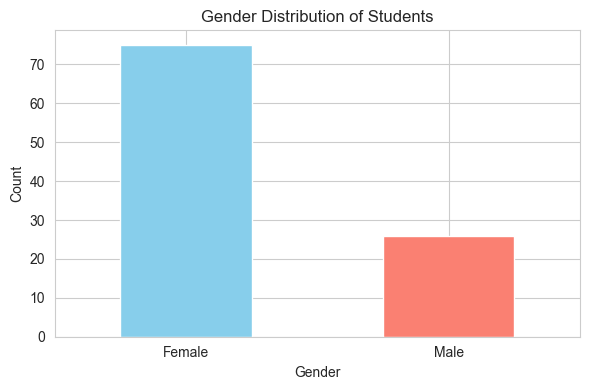

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# Make charts look nice
sns.set_style("whitegrid")

# Chart 1 - Gender distribution
plt.figure(figsize=(6,4))
df['Gender'].value_counts().plot(kind='bar', color=['skyblue', 'salmon'])
plt.title('Gender Distribution of Students')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


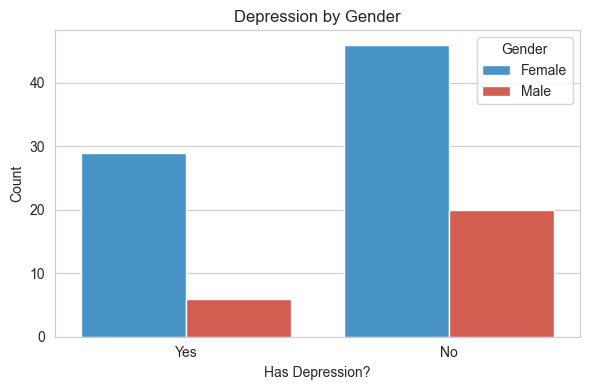

In [7]:
# Chart 2 - Depression by Gender
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='Depression', hue='Gender', palette=['#3498db', '#e74c3c'])
plt.title('Depression by Gender')
plt.xlabel('Has Depression?')
plt.ylabel('Count')
plt.tight_layout()
plt.show()


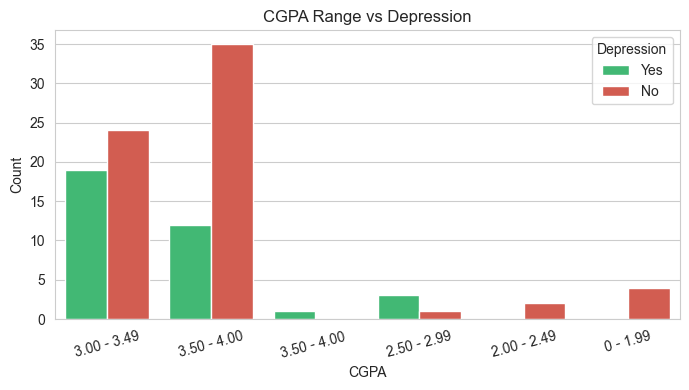

In [8]:
# Chart 3 - CGPA vs Depression
plt.figure(figsize=(7,4))
sns.countplot(data=df, x='CGPA', hue='Depression', palette=['#2ecc71', '#e74c3c'])
plt.title('CGPA Range vs Depression')
plt.xlabel('CGPA')
plt.ylabel('Count')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

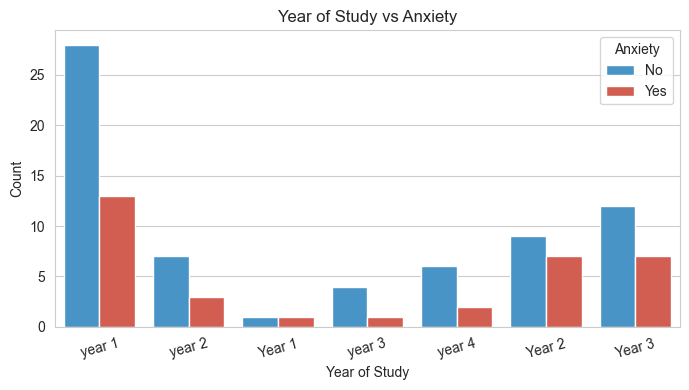

In [9]:
# Chart 4 - Year of Study vs Anxiety
plt.figure(figsize=(7,4))
sns.countplot(data=df, x='Year', hue='Anxiety', palette=['#3498db', '#e74c3c'])
plt.title('Year of Study vs Anxiety')
plt.xlabel('Year of Study')
plt.ylabel('Count')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

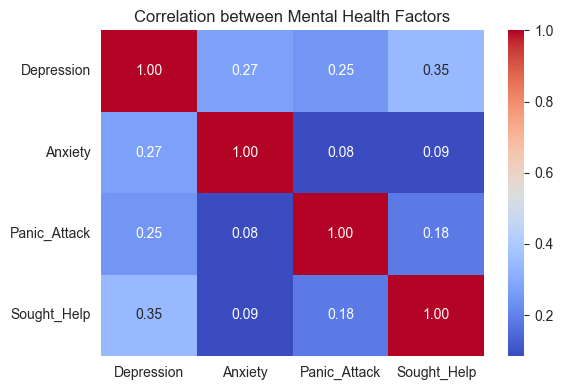

In [10]:
# Chart 5 - Correlation Heatmap
# Convert Yes/No to 1/0 for numbers
df_num = df[['Depression', 'Anxiety', 'Panic_Attack', 'Sought_Help']].copy()
df_num = df_num.apply(lambda x: x.map({'Yes': 1, 'No': 0}))

plt.figure(figsize=(6,4))
sns.heatmap(df_num.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation between Mental Health Factors')
plt.tight_layout()
plt.show()

In [11]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import LabelEncoder

# Step 1 - Pick the columns we'll use to predict
features = ['Gender', 'Age', 'Year', 'CGPA', 'Anxiety', 'Panic_Attack', 'Married']
target = 'Depression'

df_ml = df[features + [target]].copy()

# Step 2 - Convert text to numbers (ML only understands numbers)
le = LabelEncoder()
for col in df_ml.columns:
    if df_ml[col].dtype == 'object':
        df_ml[col] = le.fit_transform(df_ml[col].astype(str))

print("Data ready for ML!")
print(df_ml.head())


Data ready for ML!
   Gender   Age    Year         CGPA Anxiety Panic_Attack Married Depression
0  Female  18.0  year 1  3.00 - 3.49      No          Yes      No        Yes
1    Male  21.0  year 2  3.00 - 3.49     Yes           No      No         No
2    Male  19.0  Year 1  3.00 - 3.49     Yes          Yes      No        Yes
3  Female  22.0  year 3  3.00 - 3.49      No           No     Yes        Yes
4    Male  23.0  year 4  3.00 - 3.49      No           No      No         No


In [12]:
# Step 2 - Convert text to numbers manually (cleaner approach)
df_ml['Gender'] = df_ml['Gender'].map({'Female': 0, 'Male': 1})
df_ml['Anxiety'] = df_ml['Anxiety'].map({'No': 0, 'Yes': 1})
df_ml['Panic_Attack'] = df_ml['Panic_Attack'].map({'No': 0, 'Yes': 1})
df_ml['Married'] = df_ml['Married'].map({'No': 0, 'Yes': 1})
df_ml['Depression'] = df_ml['Depression'].map({'No': 0, 'Yes': 1})

# For CGPA and Year - use label encoding
df_ml['CGPA'] = LabelEncoder().fit_transform(df_ml['CGPA'].astype(str))
df_ml['Year'] = LabelEncoder().fit_transform(df_ml['Year'].astype(str))

print("Encoding done!")
print(df_ml.head())


Encoding done!
   Gender   Age  Year  CGPA  Anxiety  Panic_Attack  Married  Depression
0       0  18.0     3     3        0             1        0           1
1       1  21.0     4     3        1             0        0           0
2       1  19.0     0     3        1             1        0           1
3       0  22.0     5     3        0             0        1           1
4       1  23.0     6     3        0             0        0           0


In [13]:
# Step 3 - Split data into training and testing
X = df_ml[features]
y = df_ml['Depression']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training samples: {len(X_train)}")
print(f"Testing samples: {len(X_test)}")

# Step 4 - Train the model
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Step 5 - Test the model
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print(f"\nModel Accuracy: {accuracy*100:.2f}%")
print("\nDetailed Report:")
print(classification_report(y_test, y_pred))


Training samples: 80
Testing samples: 21

Model Accuracy: 71.43%

Detailed Report:
              precision    recall  f1-score   support

           0       0.71      0.92      0.80        13
           1       0.75      0.38      0.50         8

    accuracy                           0.71        21
   macro avg       0.73      0.65      0.65        21
weighted avg       0.72      0.71      0.69        21



In [14]:
# Step 3 - Split data into training and testing
X = df_ml[features]
y = df_ml['Depression']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training samples: {len(X_train)}")
print(f"Testing samples: {len(X_test)}")

# Step 4 - Train the model
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Step 5 - Test the model
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print(f"\nModel Accuracy: {accuracy*100:.2f}%")
print("\nDetailed Report:")
print(classification_report(y_test, y_pred))

Training samples: 80
Testing samples: 21

Model Accuracy: 71.43%

Detailed Report:
              precision    recall  f1-score   support

           0       0.71      0.92      0.80        13
           1       0.75      0.38      0.50         8

    accuracy                           0.71        21
   macro avg       0.73      0.65      0.65        21
weighted avg       0.72      0.71      0.69        21



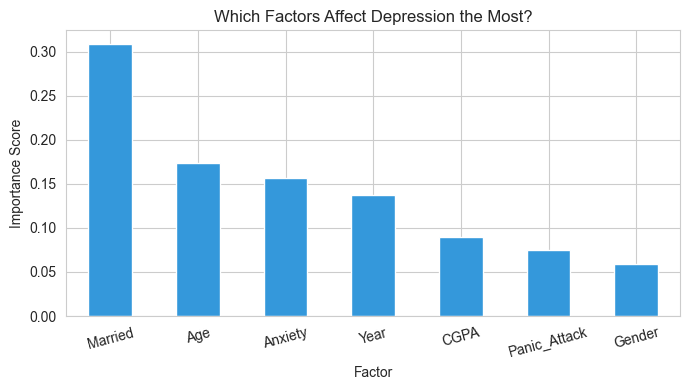

Married         0.308575
Age             0.173964
Anxiety         0.156938
Year            0.137354
CGPA            0.089627
Panic_Attack    0.074398
Gender          0.059143
dtype: float64


In [15]:
# Feature Importance - which factors affect depression the most?
import pandas as pd

importance = pd.Series(model.feature_importances_, index=features)
importance = importance.sort_values(ascending=False)

plt.figure(figsize=(7,4))
importance.plot(kind='bar', color='#3498db')
plt.title('Which Factors Affect Depression the Most?')
plt.xlabel('Factor')
plt.ylabel('Importance Score')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

print(importance)